# 3D example
This notebook shows a simple analysis pipeline for running and analyzing a 3D simulation with DISCO-DJ.

### Imports

In [1]:
# Import modules
import os
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
import jax.numpy as jnp
from discodj.cosmology.cosmology import Cosmology, Cosmology_nu
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

0.7.2


In [2]:
# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

gpu


In [8]:
cosmo = Cosmology_nu(
    Omega_c=0.25,
    Omega_b=0.05,
    h=0.67,
    sigma8=0.8,
    n_s=0.9600,
    mnu = 0.0)

cosmo_nu = Cosmology_nu(
    Omega_c=0.25,
    Omega_b=0.05,
    h=0.67,
    sigma8=0.8,
    n_s=0.96,
    mnu=0.06
)

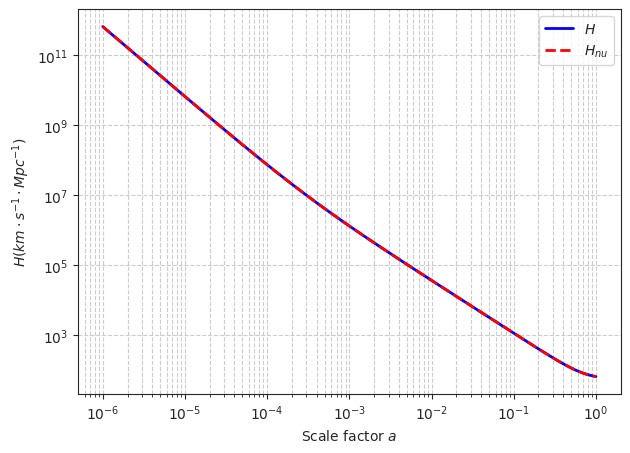

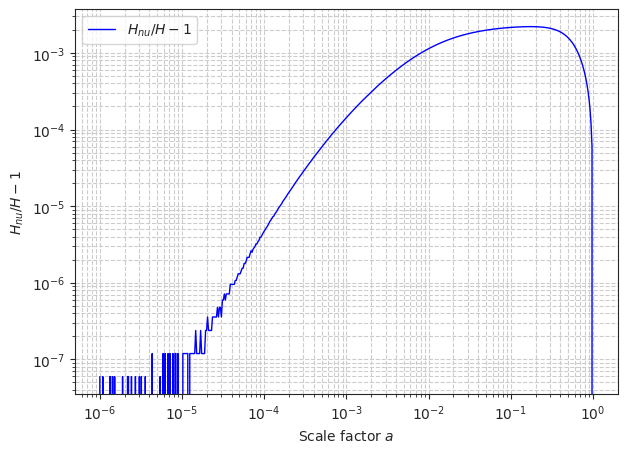

In [9]:
a = jnp.geomspace(1e-6, 1.0, 500)
H = cosmo.H(a)
H_nu = cosmo_nu.H(a)

plt.figure(figsize=(7.0, 5.0))
plt.loglog(a, H,color='blue', label=r'$H$',lw=2)  
plt.loglog(a, H_nu,'r--', label=r'$H_{nu}$',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$H (km \cdot s^{-1} \cdot Mpc^{-1}$)')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()
#plt.savefig('H.pgf')


#Plot relative deviation [(H_wnu/H)-1]
plt.figure(figsize=(7.0, 5.0))
plt.loglog(a, abs(H_nu/H -1),color='blue', label=r'$H_{nu}/H -1 $',lw=1)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$H_{nu}/H -1 $')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()

In [10]:
growth = cosmo.compute_unnormed_growth(a,1e-6)
growth_nu = cosmo_nu.compute_unnormed_growth(a,1e-6)

D1 = growth["Dplus"]
D2 = growth["D2plus"]
D1_nu = growth_nu["Dplus"]
D2_nu = growth_nu["D2plus"]

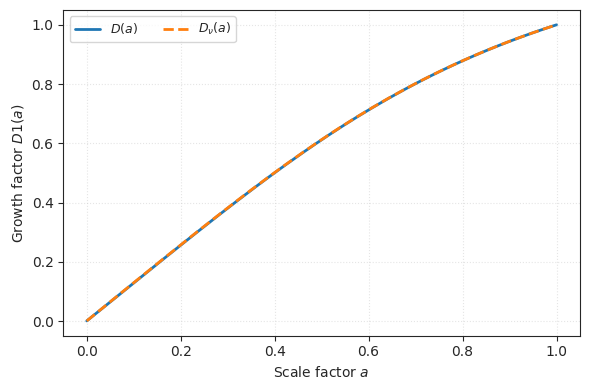

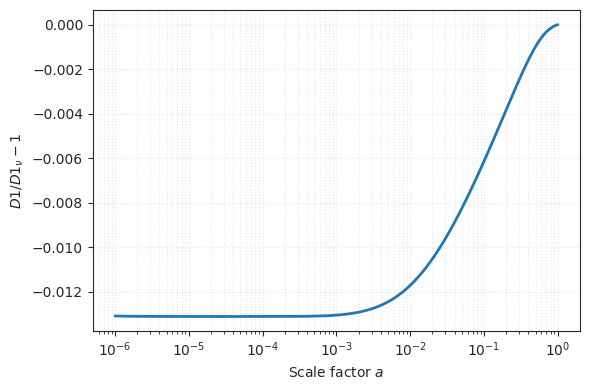

In [11]:
plt.figure(figsize=(6,4))
plt.plot(a, D1, label=r'$D(a)$', lw=2)
plt.plot(a, D1_nu, '--', label=r'$D_\nu(a)$', lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D1(a)$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()
#plt.savefig('D.pgf')

#Plot [(D/D_nu)-1] (log scale)
plt.figure(figsize=(6,4))
plt.semilogx(a, D1/D1_nu - 1, lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D1/D1_\nu - 1$')
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

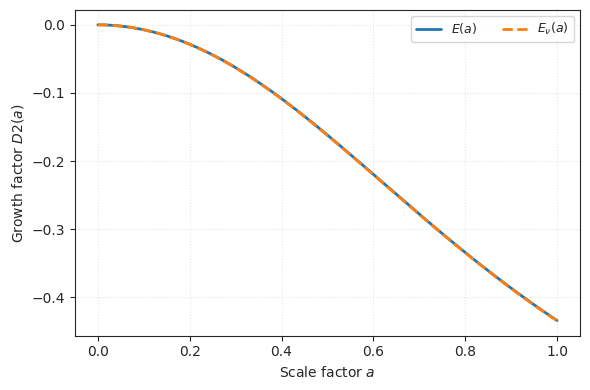

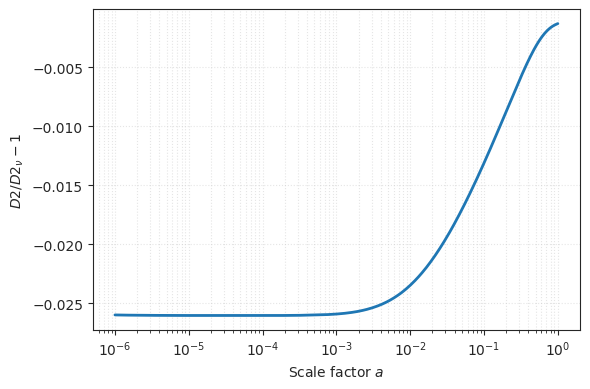

In [12]:
plt.figure(figsize=(6,4))
plt.plot(a, D2, label=r'$E(a)$', lw=2)
plt.plot(a, D2_nu, '--', label=r'$E_\nu(a)$', lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D2(a)$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()
#plt.savefig('E.pgf')

#Plot [(E/E_nu)-1] (log scale)
plt.figure(figsize=(6,4))
plt.semilogx(a, D2/D2_nu - 1, lw=2)
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D2/D2_\nu - 1$')
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()